In [3]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
import xarray as xr
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich import print
import shutil


Data coverage after join:

2014-01-01 00:00:00 to 2025-01-31 00:00:00

P       0
Ep      0
Qobs    5
dtype: int64

After dropping missing Qobs:

2014-01-01 00:00:00 to 2025-01-31 00:00:00

...

Validation RMSE    : 65.0141

Saved:

- hbv_calibration_timeseries_2014_2021.csv

- hbv_validation_timeseries_2022_2025.csv

- hbv_best_parameters.csv

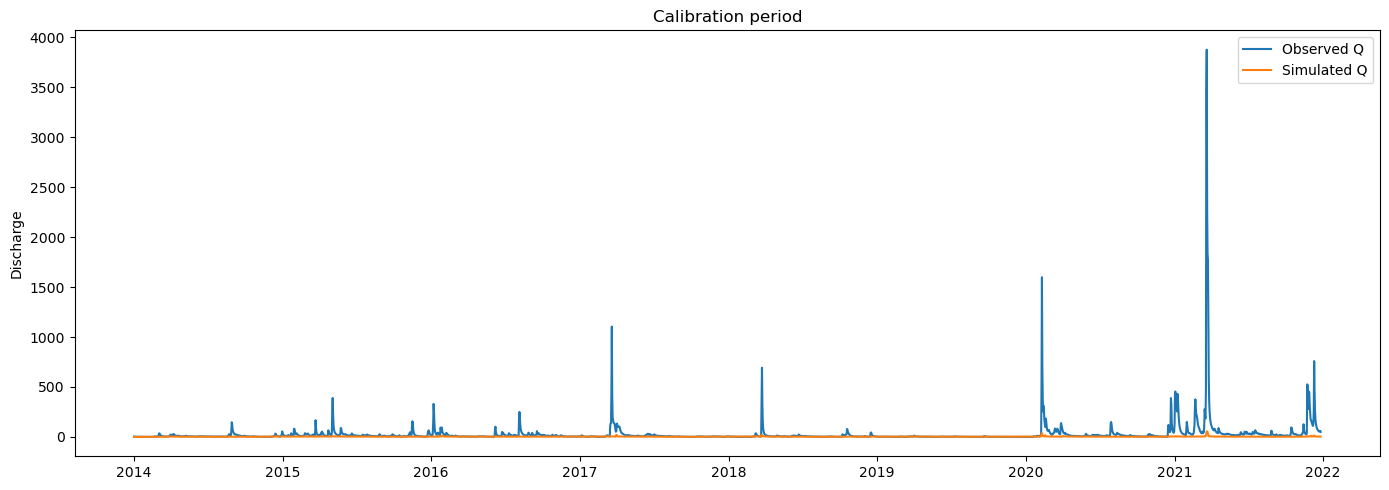

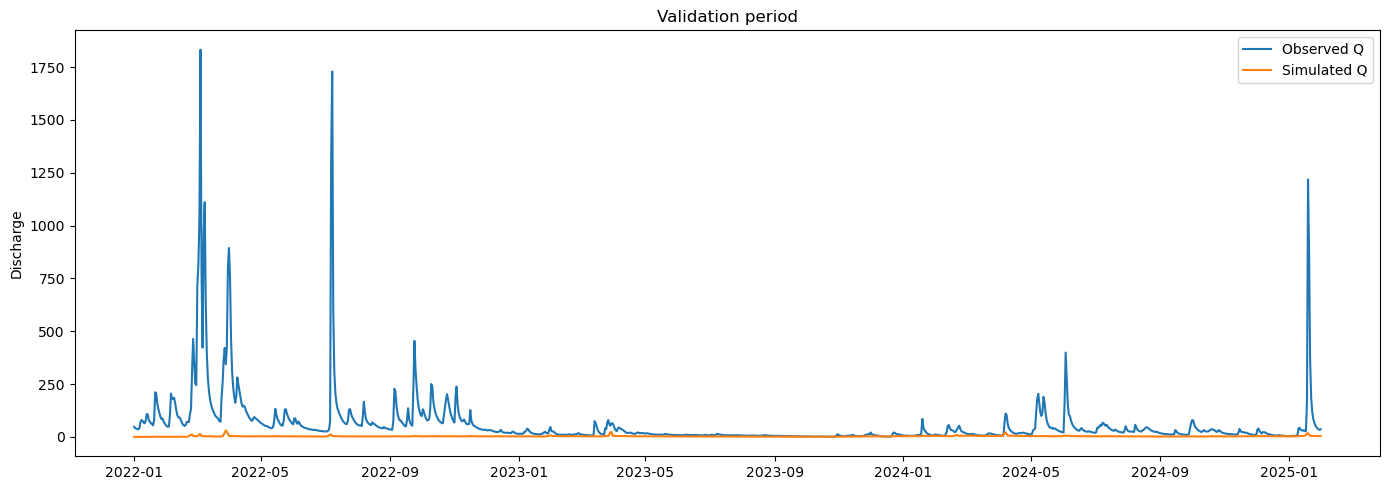

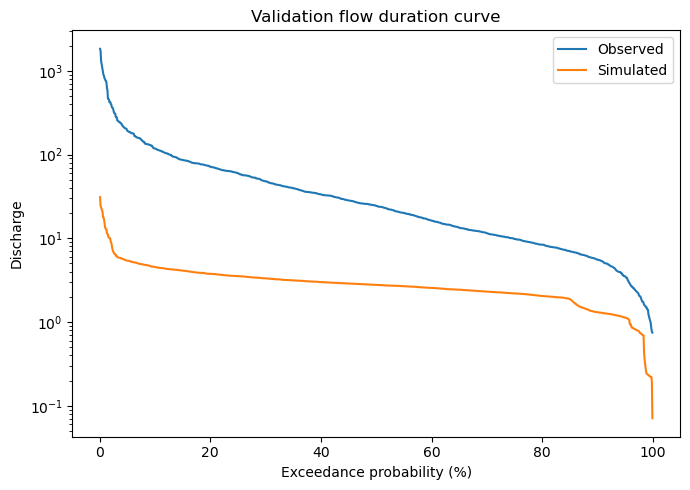

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# =========================================================
# 1. USER SETTINGS
# =========================================================
precip_file = "./Data/manning_chirps_precip_daily.csv"
evap_file   = "./Data/manning_ERA5_evap_daily.csv"
q_file      = "./Data/5202080_Q_Day.Cmd.txt"

start_date = "2014-01-01"
end_date   = "2025-01-31"

# Split calibration / validation
cal_start = "2014-01-01"
cal_end   = "2021-12-31"
val_start = "2022-01-01"
val_end   = "2025-01-31"

warmup_days = 365

# =========================================================
# 2. READ AND PREPARE DATA
# =========================================================
def load_precip(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    df["Date"] = pd.to_datetime(df["system:index"], format="%Y%m%d")
    df = df.set_index("Date")

    # pas eventueel kolomnaam aan als jouw csv anders heet
    if "precipitation" not in df.columns:
        raise ValueError("Kolom 'precipitation' niet gevonden in precipitation file.")

    df = df[["precipitation"]].rename(columns={"precipitation": "P"})
    return df


def load_evap(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    df["Date"] = pd.to_datetime(df["system:index"], format="%Y%m%d")
    df = df.set_index("Date")

    # pas eventueel kolomnaam aan als jouw csv anders heet
    if "total_evaporation_sum" not in df.columns:
        raise ValueError("Kolom 'total_evaporation_sum' niet gevonden in evap file.")

    df = df[["total_evaporation_sum"]].rename(columns={"total_evaporation_sum": "Ep"})

    # ERA5 evaporation staat vaak negatief
    df["Ep"] = df["Ep"].abs()

    return df


def load_grdc_discharge(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep=";", comment="#")
    df.columns = [c.strip() for c in df.columns]

    if "YYYY-MM-DD" not in df.columns or "Value" not in df.columns:
        raise ValueError("GRDC file bevat niet de verwachte kolommen 'YYYY-MM-DD' en 'Value'.")

    df["YYYY-MM-DD"] = pd.to_datetime(df["YYYY-MM-DD"])
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

    # GRDC missing value code
    df.loc[df["Value"] == -999.000, "Value"] = np.nan

    df = df.set_index("YYYY-MM-DD")[["Value"]].rename(columns={"Value": "Qobs"})
    return df


P = load_precip(precip_file)
E = load_evap(evap_file)
Q = load_grdc_discharge(q_file)

# Select requested period
P = P.loc[start_date:end_date].copy()
E = E.loc[start_date:end_date].copy()
Q = Q.loc[start_date:end_date].copy()

# Join on common dates
forcing = P.join(E, how="inner").join(Q, how="inner")

print("Data coverage after join:")
print(forcing.index.min(), "to", forcing.index.max())
print(forcing.isna().sum())

# For calibration we need observed discharge
forcing = forcing.dropna(subset=["Qobs"]).copy()

print("\nAfter dropping missing Qobs:")
print(forcing.index.min(), "to", forcing.index.max())
print("Number of daily records:", len(forcing))

# =========================================================
# 3. OPTIONAL UNIT CHECKS
# =========================================================
# HBV usually expects mm/day for P and Ep, and discharge in mm/day or m3/s
# Here Qobs remains in m3/s because that is what GRDC provides.
# This means the routing/scale parameter in the simple model is calibrated
# against m3/s directly.

print("\nFirst rows:")
print(forcing.head())

# =========================================================
# 4. SIMPLE HBV-LIGHT MODEL
# =========================================================
def hbv_simulate(
    P: np.ndarray,
    Ep: np.ndarray,
    params: dict,
    initial_state: dict | None = None
):
    """
    Simple HBV-light style model:
    - soil moisture reservoir
    - upper reservoir
    - lower reservoir
    - simple evap limitation
    - percolation + quickflow + baseflow

    Returns:
        Qsim: simulated discharge
        states: dict of state series
    """

    FC   = params["FC"]      # field capacity [mm]
    BETA = params["BETA"]    # runoff generation exponent [-]
    LP   = params["LP"]      # evap threshold [-]
    K0   = params["K0"]      # quickflow coefficient [1/day]
    K1   = params["K1"]      # upper zone coefficient [1/day]
    K2   = params["K2"]      # lower zone coefficient [1/day]
    UZL  = params["UZL"]     # threshold upper zone [mm]
    PERC = params["PERC"]    # percolation [mm/day]
    MAXBAS = params["MAXBAS"]  # routing window [days]

    n = len(P)

    SM = np.zeros(n + 1)   # soil moisture
    UZ = np.zeros(n + 1)   # upper zone
    LZ = np.zeros(n + 1)   # lower zone

    if initial_state is None:
        SM[0] = 0.5 * FC
        UZ[0] = 10.0
        LZ[0] = 10.0
    else:
        SM[0] = initial_state.get("SM", 0.5 * FC)
        UZ[0] = initial_state.get("UZ", 10.0)
        LZ[0] = initial_state.get("LZ", 10.0)

    Qgen = np.zeros(n)

    for t in range(n):
        p = max(P[t], 0.0)
        ep = max(Ep[t], 0.0)

        # -------------------------
        # Soil routine
        # -------------------------
        # Recharge to runoff reservoirs
        recharge = p * (SM[t] / FC) ** BETA if FC > 0 else 0.0
        recharge = min(recharge, p)

        # Effective rainfall to soil
        infil_to_soil = p - recharge

        # Update soil moisture
        SM_int = min(SM[t] + infil_to_soil, FC)

        # Actual evaporation
        evap_factor = min(SM_int / (LP * FC), 1.0) if LP * FC > 0 else 1.0
        Ea = ep * max(evap_factor, 0.0)
        Ea = min(Ea, SM_int)

        SM[t + 1] = max(SM_int - Ea, 0.0)

        # -------------------------
        # Response routine
        # -------------------------
        UZ_int = UZ[t] + recharge

        # Percolation from upper to lower zone
        perc = min(PERC, UZ_int)
        UZ_int -= perc
        LZ_int = LZ[t] + perc

        # Quickflow from upper zone above threshold
        q0 = K0 * max(UZ_int - UZL, 0.0)

        # Remaining upper zone outflow
        q1 = K1 * UZ_int

        # Lower zone outflow
        q2 = K2 * LZ_int

        # Prevent negative storage
        q0 = min(q0, UZ_int)
        UZ_int -= q0

        q1 = min(q1, UZ_int)
        UZ_int -= q1

        q2 = min(q2, LZ_int)
        LZ_int -= q2

        UZ[t + 1] = max(UZ_int, 0.0)
        LZ[t + 1] = max(LZ_int, 0.0)

        Qgen[t] = q0 + q1 + q2

    # -------------------------
    # Routing with triangular MAXBAS
    # -------------------------
    Qsim = triangular_routing(Qgen, maxbas=int(round(MAXBAS)))

    states = {
        "SM": SM[:-1],
        "UZ": UZ[:-1],
        "LZ": LZ[:-1],
        "Qgen": Qgen
    }

    return Qsim, states


def triangular_routing(q: np.ndarray, maxbas: int = 1) -> np.ndarray:
    """
    Simple triangular transfer function.
    """
    maxbas = max(1, int(maxbas))

    if maxbas == 1:
        return q.copy()

    # triangular weights
    w = np.zeros(maxbas, dtype=float)
    half = (maxbas + 1) / 2.0

    for i in range(maxbas):
        x = i + 1
        if x <= half:
            w[i] = x / half
        else:
            w[i] = (maxbas - x + 1) / (maxbas - half + 1e-12)

    w = w / w.sum()

    routed = np.convolve(q, w, mode="full")[:len(q)]
    return routed


# =========================================================
# 5. PERFORMANCE METRICS
# =========================================================
def nse(obs: np.ndarray, sim: np.ndarray) -> float:
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)

    mask = np.isfinite(obs) & np.isfinite(sim)
    obs = obs[mask]
    sim = sim[mask]

    if len(obs) == 0:
        return np.nan

    denom = np.sum((obs - np.mean(obs)) ** 2)
    if denom == 0:
        return np.nan

    return 1.0 - np.sum((obs - sim) ** 2) / denom


def lognse(obs: np.ndarray, sim: np.ndarray, eps: float = 1e-6) -> float:
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)

    mask = np.isfinite(obs) & np.isfinite(sim) & (obs >= 0) & (sim >= 0)
    obs = obs[mask]
    sim = sim[mask]

    if len(obs) == 0:
        return np.nan

    obs_log = np.log(obs + eps)
    sim_log = np.log(sim + eps)

    denom = np.sum((obs_log - np.mean(obs_log)) ** 2)
    if denom == 0:
        return np.nan

    return 1.0 - np.sum((obs_log - sim_log) ** 2) / denom


def rmse(obs: np.ndarray, sim: np.ndarray) -> float:
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    return np.sqrt(np.mean((obs[mask] - sim[mask]) ** 2))


# =========================================================
# 6. SPLIT CALIBRATION / VALIDATION
# =========================================================
cal_df = forcing.loc[cal_start:cal_end].copy()
val_df = forcing.loc[val_start:val_end].copy()

if len(cal_df) < warmup_days + 100:
    raise ValueError("Calibrationperiode is te kort voor warm-up + calibration.")

print("\nCalibration period:", cal_df.index.min(), "to", cal_df.index.max(), "n =", len(cal_df))
print("Validation period :", val_df.index.min(), "to", val_df.index.max(), "n =", len(val_df))

# =========================================================
# 7. CALIBRATION OBJECTIVE
# =========================================================
param_names = ["FC", "BETA", "LP", "K0", "K1", "K2", "UZL", "PERC", "MAXBAS"]

bounds = [
    (50.0, 1200.0),   # FC
    (0.5, 6.0),       # BETA
    (0.3, 1.0),       # LP
    (0.00, 0.8),      # K0
    (0.001, 0.5),     # K1
    (0.0001, 0.2),    # K2
    (0.0, 100.0),     # UZL
    (0.0, 10.0),      # PERC
    (1.0, 10.0)       # MAXBAS
]

def vector_to_params(x):
    return {name: val for name, val in zip(param_names, x)}

def objective(x, df, warmup=365, use_lognse_weight=0.3):
    params = vector_to_params(x)

    Qsim, _ = hbv_simulate(
        P=df["P"].values,
        Ep=df["Ep"].values,
        params=params
    )

    obs = df["Qobs"].values[warmup:]
    sim = Qsim[warmup:]

    score_nse = nse(obs, sim)
    score_lognse = lognse(obs, sim)

    if np.isnan(score_nse):
        return 1e6
    if np.isnan(score_lognse):
        score_lognse = -10.0

    # maximize combined score -> minimize negative
    combined = (1 - use_lognse_weight) * score_nse + use_lognse_weight * score_lognse
    return -combined


# =========================================================
# 8. RUN CALIBRATION
# =========================================================
print("\nStarting calibration... this may take a while.")

result = differential_evolution(
    func=objective,
    bounds=bounds,
    args=(cal_df, warmup_days, 0.3),
    strategy="best1bin",
    maxiter=40,
    popsize=12,
    tol=1e-3,
    polish=True,
    seed=42,
    updating="deferred",
    workers=1
)

best_x = result.x
best_params = vector_to_params(best_x)

print("\nCalibration finished.")
print("Best objective:", result.fun)
print("Best parameters:")
for k, v in best_params.items():
    print(f"{k:>7s} = {v:.6f}")

# =========================================================
# 9. RUN MODEL WITH BEST PARAMETERS
# =========================================================
Qsim_cal, states_cal = hbv_simulate(
    P=cal_df["P"].values,
    Ep=cal_df["Ep"].values,
    params=best_params
)

Qsim_val, states_val = hbv_simulate(
    P=val_df["P"].values,
    Ep=val_df["Ep"].values,
    params=best_params
)

# =========================================================
# 10. EVALUATION
# =========================================================
obs_cal = cal_df["Qobs"].values[warmup_days:]
sim_cal = Qsim_cal[warmup_days:]

obs_val = val_df["Qobs"].values[warmup_days:] if len(val_df) > warmup_days else val_df["Qobs"].values
sim_val = Qsim_val[warmup_days:] if len(val_df) > warmup_days else Qsim_val

print("\nPerformance:")
print(f"Calibration NSE    : {nse(obs_cal, sim_cal):.4f}")
print(f"Calibration logNSE : {lognse(obs_cal, sim_cal):.4f}")
print(f"Calibration RMSE   : {rmse(obs_cal, sim_cal):.4f}")

print(f"Validation NSE     : {nse(obs_val, sim_val):.4f}")
print(f"Validation logNSE  : {lognse(obs_val, sim_val):.4f}")
print(f"Validation RMSE    : {rmse(obs_val, sim_val):.4f}")

# =========================================================
# 11. SAVE RESULTS
# =========================================================
cal_out = cal_df.copy()
cal_out["Qsim"] = Qsim_cal

val_out = val_df.copy()
val_out["Qsim"] = Qsim_val

cal_out.to_csv("hbv_calibration_timeseries_2014_2021.csv")
val_out.to_csv("hbv_validation_timeseries_2022_2025.csv")

params_df = pd.DataFrame([best_params])
params_df.to_csv("hbv_best_parameters.csv", index=False)

print("\nSaved:")
print("- hbv_calibration_timeseries_2014_2021.csv")
print("- hbv_validation_timeseries_2022_2025.csv")
print("- hbv_best_parameters.csv")

# =========================================================
# 12. PLOTS
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(cal_df.index, cal_df["Qobs"], label="Observed Q")
plt.plot(cal_df.index, Qsim_cal, label="Simulated Q")
plt.title("Calibration period")
plt.ylabel("Discharge")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(val_df.index, val_df["Qobs"], label="Observed Q")
plt.plot(val_df.index, Qsim_val, label="Simulated Q")
plt.title("Validation period")
plt.ylabel("Discharge")
plt.legend()
plt.tight_layout()
plt.show()

# Flow duration curve
def flow_duration_curve(q):
    q = np.asarray(q, dtype=float)
    q = q[np.isfinite(q)]
    q = np.sort(q)[::-1]
    exceed = np.arange(1, len(q) + 1) / (len(q) + 1) * 100.0
    return exceed, q

exc_obs, fdc_obs = flow_duration_curve(val_df["Qobs"].values)
exc_sim, fdc_sim = flow_duration_curve(Qsim_val)

plt.figure(figsize=(7, 5))
plt.semilogy(exc_obs, fdc_obs, label="Observed")
plt.semilogy(exc_sim, fdc_sim, label="Simulated")
plt.xlabel("Exceedance probability (%)")
plt.ylabel("Discharge")
plt.title("Validation flow duration curve")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# COMPLETE HBV eWaterCycle CALIBRATION SCRIPT
# For Manning catchment using:
#   - CHIRPS precipitation
#   - ERA5 evaporation
#   - GRDC discharge
# Period: 2014-01-01 to 2025-01-31


# ============================================================
# 1. FILE PATHS
# ============================================================
precip_file = "./Data/manning_chirps_precip_daily.csv"
evap_file   = "./Data/manning_ERA5_evap_daily.csv"
q_file      = "./Data/5202080_Q_Day.Cmd.txt"

# output forcing netcdf
forcing_nc = "./Data/manning_hbv_forcing_2014_2025.nc"

# model period
experiment_start_time = "2014-01-01T00:00:00Z"
experiment_end_time   = "2025-01-31T00:00:00Z"

# calibration period
calibration_start_time = "2015-01-01"
calibration_end_time   = "2021-12-31"

# validation period
validation_start_time = "2022-01-01"
validation_end_time   = "2025-01-31"

# catchment area
# GRDC header says 6642.0 km² for KILLAWARRA
shape_area_km2 = 6642.0
shape_area = shape_area_km2 * 1e6   # m²


# ============================================================
# 2. BUILD CUSTOM FORCING NETCDF FROM YOUR CSV FILES
#    This creates one NetCDF with variables:
#       - pr
#       - evspsblpot
# ============================================================

# precipitation
P = pd.read_csv(precip_file)
P["time"] = pd.to_datetime(P["system:index"], format="%Y%m%d")
P = P.set_index("time")

# adjust if your precipitation column has a different name
P = P[["precipitation"]].rename(columns={"precipitation": "pr"})

# evaporation
E = pd.read_csv(evap_file)
E["time"] = pd.to_datetime(E["system:index"], format="%Y%m%d")
E = E.set_index("time")

# adjust if your evaporation column has a different name
E = E[["total_evaporation_sum"]].rename(columns={"total_evaporation_sum": "evspsblpot"})

# ERA5 evaporation is often stored negative
E["evspsblpot"] = E["evspsblpot"].abs()

# merge and subset period
forcing_df = P.join(E, how="inner")
forcing_df = forcing_df.loc["2014-01-01":"2025-01-31"].copy()

print("Forcing period:")
print(forcing_df.index.min(), "to", forcing_df.index.max())
print("Number of days:", len(forcing_df))
print(forcing_df.head())

# convert to xarray dataset
ds_forcing = xr.Dataset(
    data_vars={
        "pr": ("time", forcing_df["pr"].values),
        "evspsblpot": ("time", forcing_df["evspsblpot"].values),
    },
    coords={"time": forcing_df.index.values},
    attrs={
        "title": "HBV forcing for Manning catchment",
        "history": "Created from CHIRPS daily precipitation and ERA5 daily evaporation"
    }
)

ds_forcing["pr"].attrs["units"] = "mm/day"
ds_forcing["evspsblpot"].attrs["units"] = "mm/day"

ds_forcing.to_netcdf(forcing_nc)
print(f"\nSaved forcing NetCDF to: {forcing_nc}")


# ============================================================
# 3. LOAD GRDC OBSERVATIONS
# ============================================================

obs = pd.read_csv(q_file, sep=";", comment="#")
obs.columns = [c.strip() for c in obs.columns]

obs["YYYY-MM-DD"] = pd.to_datetime(obs["YYYY-MM-DD"])
obs["Value"] = pd.to_numeric(obs["Value"], errors="coerce")

# GRDC missing value code
obs.loc[obs["Value"] == -999.000, "Value"] = np.nan

obs = obs.set_index("YYYY-MM-DD")[["Value"]].rename(columns={"Value": "Q"})
obs = obs.loc["2014-01-01":"2025-01-31"].copy()

print("\nObservation period:")
print(obs.index.min(), "to", obs.index.max())
print("Number of days:", len(obs))
print(obs.head())


# ============================================================
# 4. CREATE HBVForcing OBJECT
# ============================================================

ERA5_forcing = HBVForcing(
    directory=Path("./Data"),
    start_time=experiment_start_time,
    end_time=experiment_end_time,
    pr="manning_hbv_forcing_2014_2025.nc",
    evspsblpot="manning_hbv_forcing_2014_2025.nc"
)


# ============================================================
# 5. PARAMETER AND INITIAL STORAGE SETTINGS
#    Parameter names from your HBV wrapper:
#       Imax, Ce, Sumax, Beta, Pmax, Tlag, Kf, Ks
# ============================================================

# initial storages
# Si, Su, Sf, Ss
s_0 = np.array([0.0, 100.0, 5.0, 20.0])
s_names = ["Interception storage", "Unsaturated Rootzone Storage", "Fastflow storage", "Groundwater storage"]

# parameter names
p_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks"]

# ensemble size
N = 100

# parameter ranges
#                Imax   Ce   Sumax  Beta  Pmax  Tlag   Kf      Ks
p_min_initial = np.array([0.0,  0.4,  40.0,  1.0,  0.001,  1.0,  0.01,   0.0001])
p_max_initial = np.array([8.0,  0.8, 800.0,  2.5,  0.3,   8.0,  0.10,   0.01])

parameters = np.zeros((8, N))

np.random.seed(6)
for param in range(8):
    parameters[param, :] = np.random.uniform(
        p_min_initial[param],
        p_max_initial[param],
        N
    )

print("\nRandom parameter ensemble created with shape:", parameters.shape)


# ============================================================
# 6. CREATE ENSEMBLE OF MODELS
#    This follows the same structure as your example notebook
# ============================================================

ensemble = []

for counter in range(N):
    ensemble.append(HBV(forcing=ERA5_forcing))

    config_file, _ = ensemble[counter].setup(
        parameters=",".join([str(p) for p in parameters[:, counter]]),
        initial_storage=",".join([str(s) for s in s_0]),
        cfg_dir="configFiles/hbv_ensembleMember_" + str(counter),
    )

    ensemble[counter].initialize(config_file)

print(f"\nInitialized {N} HBV ensemble members.")


# ============================================================
# 7. OBJECTIVE FUNCTIONS
#    We calculate:
#       - NSE
#       - log NSE
# ============================================================

def calibrationObjective(modelOutput, observation, start_calibration, end_calibration):
    """
    Returns:
        nse_value, log_nse_value
    """

    hydro_data = pd.concat(
        [modelOutput.reindex(observation.index, method="ffill"), observation],
        axis=1
    )

    hydro_data = hydro_data[hydro_data.index >= pd.to_datetime(pd.Timestamp(start_calibration).date())]
    hydro_data = hydro_data[hydro_data.index <= pd.to_datetime(pd.Timestamp(end_calibration).date())]

    hydro_data = hydro_data.dropna()

    sim = hydro_data["model output"].values
    obs_vals = hydro_data["Q"].values

    # NSE
    denom = np.sum((obs_vals - np.mean(obs_vals)) ** 2)
    if denom == 0:
        nse_value = np.nan
    else:
        nse_value = 1.0 - np.sum((obs_vals - sim) ** 2) / denom

    # log NSE
    eps = 1e-6
    sim_log = np.log(sim + eps)
    obs_log = np.log(obs_vals + eps)

    denom_log = np.sum((obs_log - np.mean(obs_log)) ** 2)
    if denom_log == 0:
        log_nse_value = np.nan
    else:
        log_nse_value = 1.0 - np.sum((obs_log - sim_log) ** 2) / denom_log

    return nse_value, log_nse_value


# ============================================================
# 8. RUN ALL ENSEMBLE MEMBERS
#    Model Q is in mm/day
#    Convert to m³/s using:
#      Q(m3/s) = Q(mm/day) * area(m²) / (1000 * 86400)
# ============================================================

if USE_PROGRESS:
    f = IntProgress(min=0, max=N)
    display(f)

objectives = []
all_model_outputs = []

for ensembleMember in ensemble:
    Q_m = []
    time = []

    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()

        discharge_this_timestep = ensembleMember.get_value("Q") * shape_area / (1000.0 * 86400.0)

        Q_m.append(discharge_this_timestep[0])
        time.append(pd.Timestamp(ensembleMember.time_as_datetime.date()))

    discharge_dataframe = pd.DataFrame(
        {"model output": Q_m},
        index=pd.to_datetime(time)
    )

    objective_this_model = calibrationObjective(
        discharge_dataframe,
        obs,
        calibration_start_time,
        calibration_end_time
    )

    objectives.append(objective_this_model)
    all_model_outputs.append(discharge_dataframe)

    if USE_PROGRESS:
        f.value += 1

print("\nFinished all ensemble runs.")


# ============================================================
# 9. FINALIZE MODELS
# ============================================================

for ensembleMember in ensemble:
    ensembleMember.finalize()

print("All models finalized.")


# ============================================================
# 10. ANALYSE RESULTS
# ============================================================

nse_values = [i[0] for i in objectives]
log_nse_values = [i[1] for i in objectives]

best_nse_index = int(np.nanargmax(nse_values))
best_log_nse_index = int(np.nanargmax(log_nse_values))

best_nse_params = parameters[:, best_nse_index]
best_log_nse_params = parameters[:, best_log_nse_index]

print("\nBest NSE index:", best_nse_index)
print("Best NSE value:", nse_values[best_nse_index])
print("Best NSE parameters:")
for name, val in zip(p_names, best_nse_params):
    print(f"  {name:>5s} = {val:.6f}")

print("\nBest log NSE index:", best_log_nse_index)
print("Best log NSE value:", log_nse_values[best_log_nse_index])
print("Best log NSE parameters:")
for name, val in zip(p_names, best_log_nse_params):
    print(f"  {name:>5s} = {val:.6f}")


# ============================================================
# 11. PLOT PARAMETER VS NSE / log NSE
# ============================================================

xFigNr = 2
yFigNr = 4

fig_nse, axs_nse = plt.subplots(xFigNr, yFigNr, figsize=(15, 15))
fig_lognse, axs_lognse = plt.subplots(xFigNr, yFigNr, figsize=(15, 15))

for xFig in range(xFigNr):
    for yFig in range(yFigNr):
        paramCounter = xFig * yFigNr + yFig

        axs_nse[xFig, yFig].plot(parameters[paramCounter, :], nse_values, ".", label="NSE")
        axs_nse[xFig, yFig].set_title(p_names[paramCounter])
        axs_nse[xFig, yFig].legend()

        axs_lognse[xFig, yFig].plot(parameters[paramCounter, :], log_nse_values, ".", label="log NSE")
        axs_lognse[xFig, yFig].set_title(p_names[paramCounter])
        axs_lognse[xFig, yFig].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 12. PLOT BEST CALIBRATION MEMBER AGAINST OBSERVATIONS
# ============================================================

best_model_output = all_model_outputs[best_nse_index].copy()
best_model_output = best_model_output.reindex(obs.index, method="ffill")

plot_df = pd.concat([obs, best_model_output], axis=1)
plot_df = plot_df.loc["2014-01-01":"2025-01-31"]

plt.figure(figsize=(16, 5))
plt.plot(plot_df.index, plot_df["Q"], label="Observed Q")
plt.plot(plot_df.index, plot_df["model output"], label="Best NSE model output")
plt.title("Observed vs Best NSE simulated discharge")
plt.ylabel("Discharge [m³/s]")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 13. CALCULATE NSE FOR VALIDATION PERIOD AS WELL
# ============================================================

validation_scores = calibrationObjective(
    best_model_output,
    obs,
    validation_start_time,
    validation_end_time
)

print("\nValidation performance of best-NSE member:")
print("Validation NSE    :", validation_scores[0])
print("Validation log NSE:", validation_scores[1])


# ============================================================
# 14. SAVE RESULTS
# ============================================================

results_df = pd.DataFrame({
    "member": np.arange(N),
    "NSE": nse_values,
    "logNSE": log_nse_values,
    "Imax": parameters[0, :],
    "Ce": parameters[1, :],
    "Sumax": parameters[2, :],
    "Beta": parameters[3, :],
    "Pmax": parameters[4, :],
    "Tlag": parameters[5, :],
    "Kf": parameters[6, :],
    "Ks": parameters[7, :]
})

results_df.to_csv("./Data/hbv_ensemble_results_2014_2025.csv", index=False)
plot_df.to_csv("./Data/hbv_best_member_timeseries_2014_2025.csv")

print("\nSaved:")
print("./Data/hbv_ensemble_results_2014_2025.csv")
print("./Data/hbv_best_member_timeseries_2014_2025.csv")

Forcing period:

2014-01-01 00:00:00 to 2025-01-31 00:00:00

Number of days: 4049

pr  evspsblpot
time                            
2014-01-01  0.000000    0.003428
2014-01-02  0.000000    0.002923
2014-01-03  0.000000    0.003176
2014-01-04  0.542302    0.003262
2014-01-05  0.000000    0.003388

Saved forcing NetCDF to: ./Data/manning_hbv_forcing_2014_2025.nc

Observation period:

2014-01-01 00:00:00 to 2025-01-31 00:00:00

Number of days: 4049

Q
YYYY-MM-DD       
2014-01-01  3.837
2014-01-02  3.232
2014-01-03  2.674
2014-01-04  2.170
2014-01-05  1.788

NameError: name 'HBVForcing' is not defined